In [ ]:
!pip install xgboost imbalanced-learn shap lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import shap


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cirrhosis-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cirrhosis-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/cirrhosis-prediction-dataset


In [ ]:
import os

# Load the dataset
df = pd.read_csv(os.path.join(path, 'cirrhosis.csv'))

df.drop(columns=['ID'], inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Status', axis=1)
y = df['Status']


In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:", np.bincount(y_res))


After SMOTE: [232 232 232]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)


In [ ]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8714285714285714

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84        46
           1       0.92      0.98      0.95        47
           2       0.84      0.81      0.83        47

    accuracy                           0.87       140
   macro avg       0.87      0.87      0.87       140
weighted avg       0.87      0.87      0.87       140


Confusion Matrix:
 [[38  1  7]
 [ 1 46  0]
 [ 6  3 38]]


In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_res, y_res, cv=kf, scoring='accuracy')

print("K-Fold Accuracy:", cv_scores.mean() * 100)


K-Fold Accuracy: 86.21325051759834


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_ * 100)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Accuracy: 84.8906048906049


/tmp/ipython-input-1491325401.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


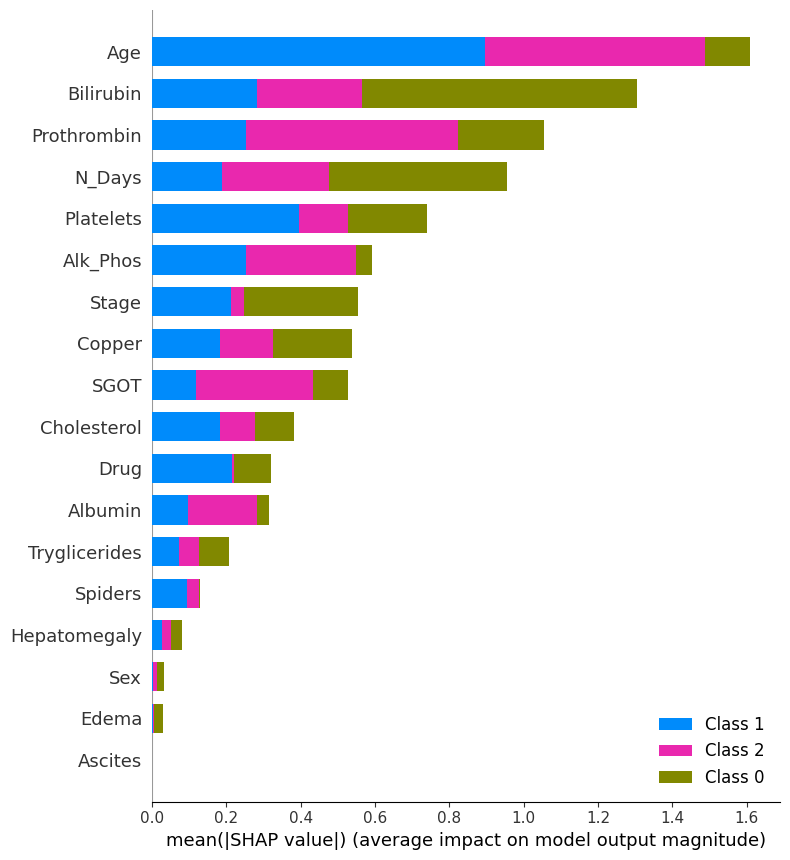

In [ ]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


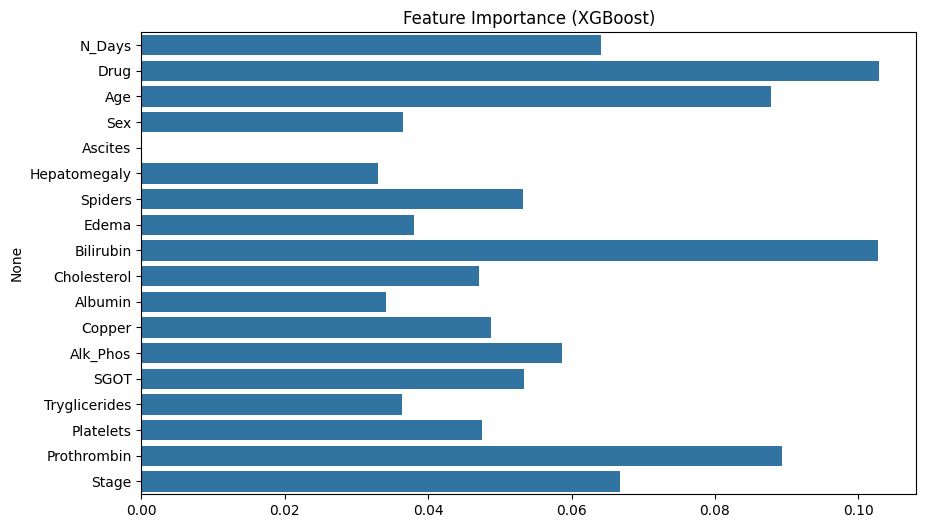

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=xgb.feature_importances_, y=X.columns)
plt.title("Feature Importance (XGBoost)")
plt.show()
